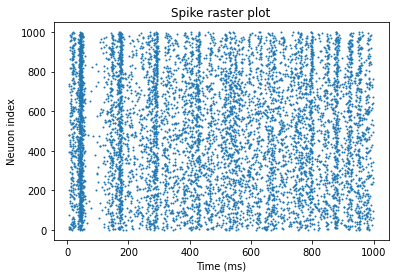

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Ne = 800
Ni = 200

re = np.random.rand(Ne, 1)
ri = np.random.rand(Ni, 1)

a = np.concatenate((0.02 * np.ones((Ne, 1)),
                    0.02 + 0.08 * ri))

b = np.concatenate((0.2 * np.ones((Ne, 1)),
                    0.25 - 0.05 * ri))

c = np.concatenate((-65 + 15 * re**2,
                    -65 * np.ones((Ni, 1))))

d = np.concatenate((8 - 6 * re**2,
                    2 * np.ones((Ni, 1))))

S = np.concatenate((0.5 * np.random.rand(Ne + Ni, Ne),
                    -np.random.rand(Ne + Ni, Ni)), axis=1)

v = -65 * np.ones((Ne + Ni, 1))
u = b * v       

firings = []

for t in range(1000):  # 1000 ms
    I = np.concatenate((5 * np.random.randn(Ne, 1),
                        2 * np.random.randn(Ni, 1)))

    fired = np.where(v >= 30)[0]  # indices of spikes

    if len(fired) > 0:
        firings.extend([(t, i) for i in fired])

        v[fired] = c[fired]
        u[fired] = u[fired] + d[fired]

        I = I + np.sum(S[:, fired], axis=1, keepdims=True)

    v = v + 0.5 * (0.04 * v**2 + 5 * v + 140 - u + I)
    v = v + 0.5 * (0.04 * v**2 + 5 * v + 140 - u + I)
    u = u + a * (b * v - u)

firings = np.array(firings)

plt.scatter(firings[:, 0], firings[:, 1], s=1)
plt.xlabel("Time (ms)")
plt.ylabel("Neuron index")
plt.title("Spike raster plot")
plt.show()


In [13]:
def izhikevich_model(v, u, I, a, b):
    dv = 0.04*v**2 + 5*v + 140 - u + I
    du = a*(b*v - u)

    return dv, du

In [8]:
# 
def I_input(t):
    if 10 < t < 40:
        return 10
    return 0

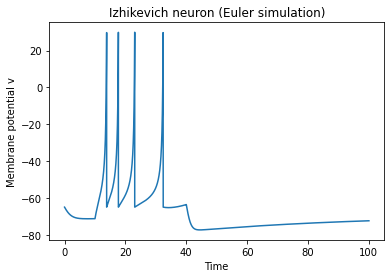

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# values of a,b,c,d from paper
a = 0.02
b = 0.2
c = -65
d = 2

#spike condition
spike_condition = 30 

#time step size
dt = 0.001
#total simulation time - from 1 to 100
T = 100
# array of points - start: 0, end: T, step: dt 
time = np.arange(0, T, dt)
# we do it to simulate time

# initial values
v = -65
u=b*v

# store how v and u change over time
v_trace = []
u_trace = []


for t in time: # we go through every time step 0 - 0.25, 0.5, 0.75 and so on
    I = I_input(t) # we compute the external current injected into the neuron at time t - from 0 to 10 it is 0 and from 10 to 40 ms the current is 10 

    # we compute the model variables - how fast u (recovery variable) and v (voltage) are changing
    dv, du = izhikevich_model(v, u, I, a, b)

    # Euler update - new value = old value + (rate of change × time step)
    v += dt * dv
    u += dt * du

    # spike condition - if voltage over 30 a spike happens => then voltage is reset to baseline value => recovery variable increases and the neuron becomes inactive
    if v >= spike_condition:
        v = c
        u += d

    # we save the new values of v and u
    v_trace.append(v)
    u_trace.append(u)

# draw graphics
plt.plot(time, v_trace)
plt.title("Izhikevich neuron (Euler simulation)")
plt.xlabel("Time")
plt.ylabel("Membrane potential v")
plt.show()

